In [17]:
import sys
sys.path.append("..")

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from DicomToNumpyClass import DicomToNumpy
from preprocessor.preprocessor import CTManager
from brain_extraction.brain_extractor import BrainExtractorManager
from kernel_extraction.kernel_extractor import KernelExtractorManager

In [19]:
processor = DicomToNumpy("../Brain_Stroke_CT_Dataset")
subdataset = processor.get_subset(limit = 1000) # tomo solo las 1000 primeras imágenes
subdataset_filtered = CTManager.process_batch_clean_image(subdataset)
subdataset_filtered = BrainExtractorManager(subdataset_filtered).extract_all_brains(plot_examples=False)
kernel_manager = KernelExtractorManager(subdataset_filtered, patch_size=32)
kernels_dataset = kernel_manager.extract_all(patches_per_lesion=3)

Cargando subconjunto de datos (Primeras 1000 imágenes)...
  -> Cargado subconjunto Bleeding: (1000, 512, 512)
  -> Cargado subconjunto Ischemia: (1000, 512, 512)
  -> Cargado subconjunto Normal: (1000, 512, 512)
Iniciando extracción de cerebros...
  -> Procesando clase: Bleeding (1000 imágenes)
  -> Procesando clase: Ischemia (1000 imágenes)
  -> Procesando clase: Normal (1000 imágenes)
Extracción completada.
Iniciando extracción de kernels (32x32)...
  -> Procesando Bleeding...
  -> Procesando Ischemia...

  -> Balanceando patologías al mínimo común: 2884 parches.
  -> Procesando Normal (Buscando 2884 parches para balance 1:1:1)...
--------------------------------------------------
RESUMEN DE KERNELS EXTRAÍDOS (BALANCE ESTRICTO 1:1:1):
[Bleeding]: 2884 parches de tamaño 32x32
[Ischemia]: 2884 parches de tamaño 32x32
[Normal]: 2884 parches de tamaño 32x32
--------------------------------------------------


## Feature Extractor
Obtengo Kernels de 32x32 de cada tejido:
- Normal: proviene de 'brain' (tejido sano).
- Ischemia/Bleeding: proviene de 'overlay' (tejido no sano).

In [20]:
from feature_analysis.utils import save_kernels_dataset, plot_feature_distributions
from feature_analysis.feature_extract import FeatureExtractManager

In [21]:
feature_manager = FeatureExtractManager(kernels_dataset)
df_features = feature_manager.extract_all_to_dataframe()

Iniciando extracción radiómica (First-Order, GLCM, LDOP-Gradients)...
  -> Minando características para clase: Bleeding (2884 parches)
  -> Minando características para clase: Ischemia (2884 parches)
  -> Minando características para clase: Normal (2884 parches)
--------------------------------------------------
EXTRACCIÓN COMPLETADA.
Dataset estructurado final: 8652 filas (ejemplos) x 15 columnas (features + label)
--------------------------------------------------


Generando gráficos estadísticos...


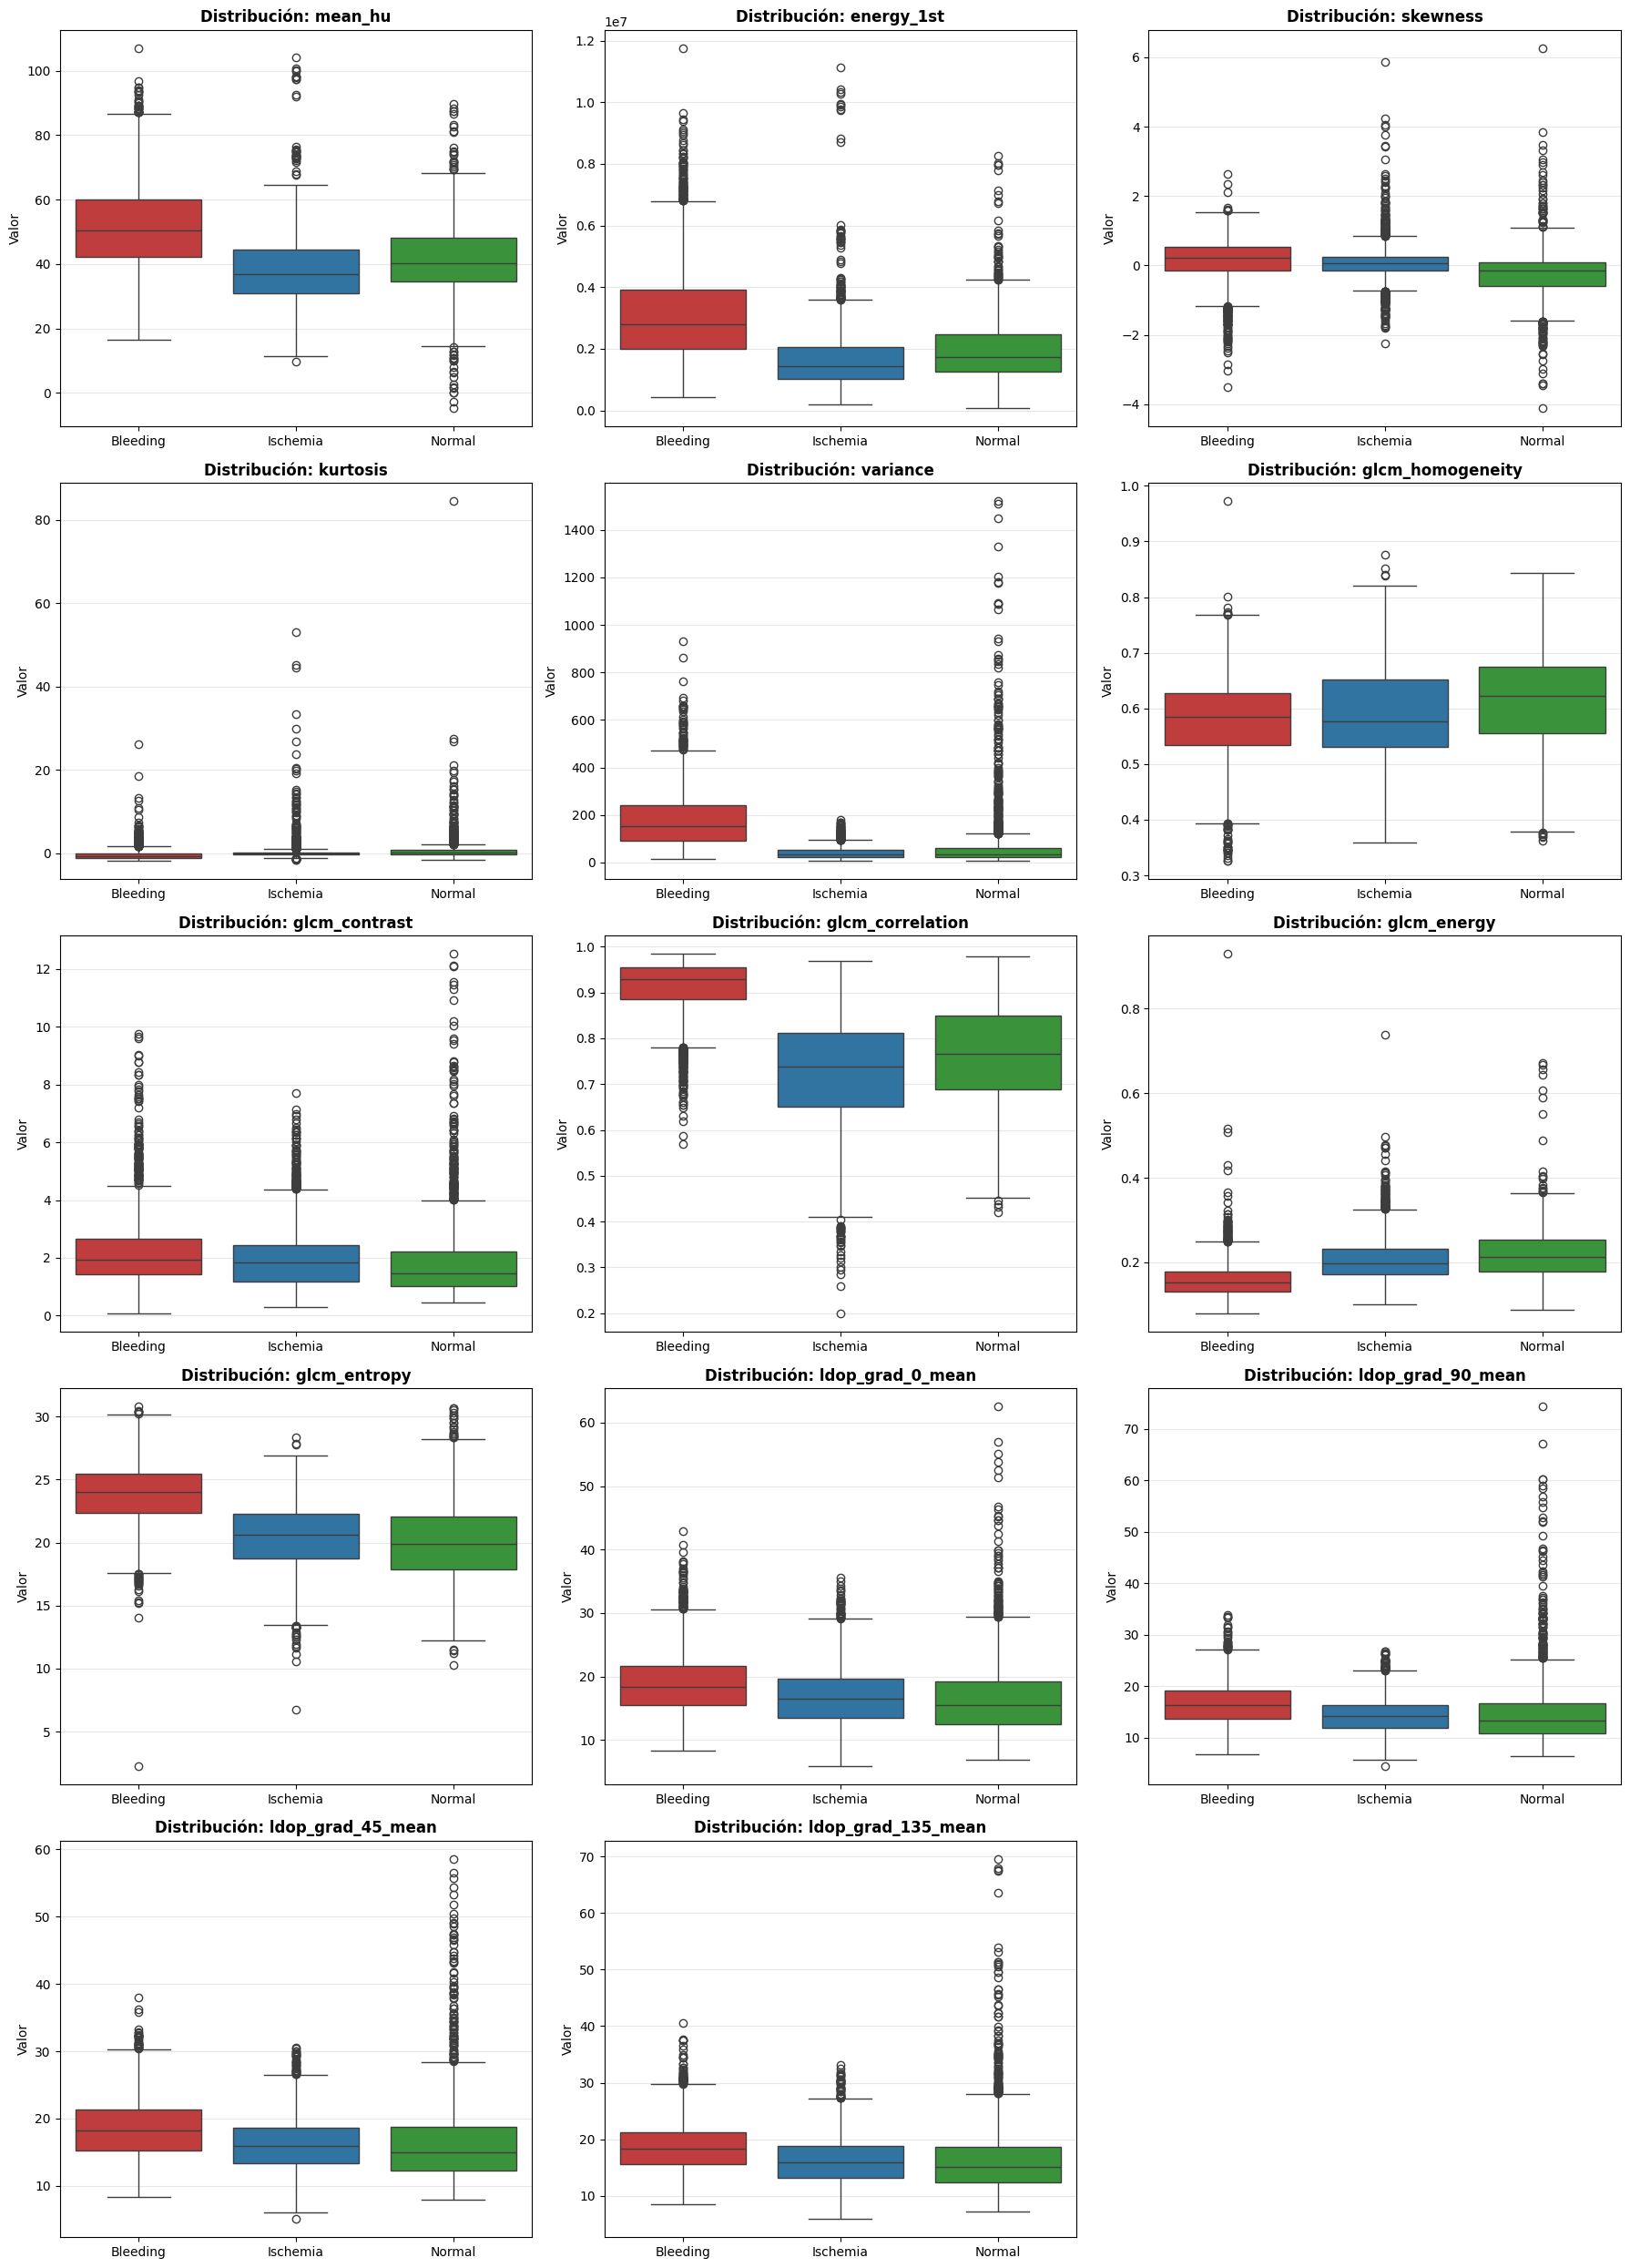

In [22]:
plot_feature_distributions(df_features)

# Almacenamiento del Kernel
Para no volver a correr los códigos para general los kernels (que lleva su tiempo) lo almaceno como NumPy.

In [23]:
save_kernels_dataset(kernels_dataset)

--------------------------------------------------
ÉXITO: Dataset de kernels guardado en '..\Kernels_datasets_numpy\kernel_dataset_4.npy'
--------------------------------------------------


WindowsPath('../Kernels_datasets_numpy/kernel_dataset_4.npy')

# Análisis de Características
Ahora analizo que features son mejores para entrenar al modelo.
- primero, a partir de un pequeño Random-Forest, veo que features tienen mejor Score.
- segundo, a partir de la correlación de Pearson, veo si hay features que brindan la misma información (lo que puede confundir al modelo).


--- RANKING DE CARACTERÍSTICAS ---
        Caracteristica  Score_Final  Info_Mutua  RF_Importancia
0             variance     1.000000    0.315456        0.128660
1     glcm_correlation     0.954523    0.299481        0.123474
2           energy_1st     0.608987    0.155818        0.093154
3              mean_hu     0.560650    0.144551        0.085311
4         glcm_entropy     0.542911    0.165601        0.072161
5             kurtosis     0.509199    0.145564        0.071658
6             skewness     0.491574    0.091744        0.089074
7          glcm_energy     0.469528    0.153520        0.058205
8    ldop_grad_90_mean     0.334045    0.076243        0.054860
9   ldop_grad_135_mean     0.288936    0.076213        0.043265
10   ldop_grad_45_mean     0.282012    0.065958        0.045666
11    glcm_homogeneity     0.271098    0.048924        0.049805
12       glcm_contrast     0.245279    0.040448        0.046618
13    ldop_grad_0_mean     0.228992    0.051087        0.038088


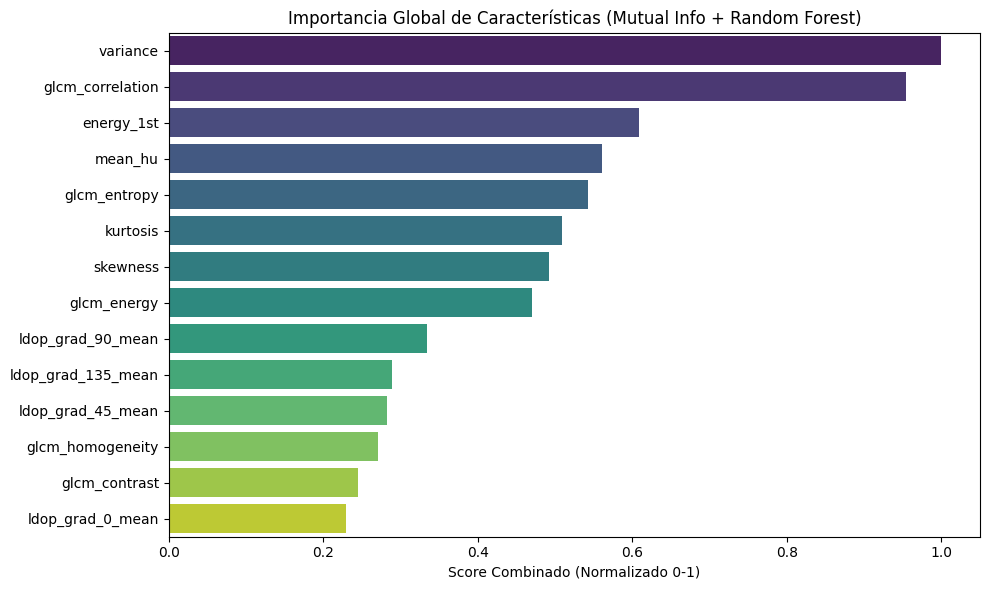

Calculando matriz de correlación cruzada...


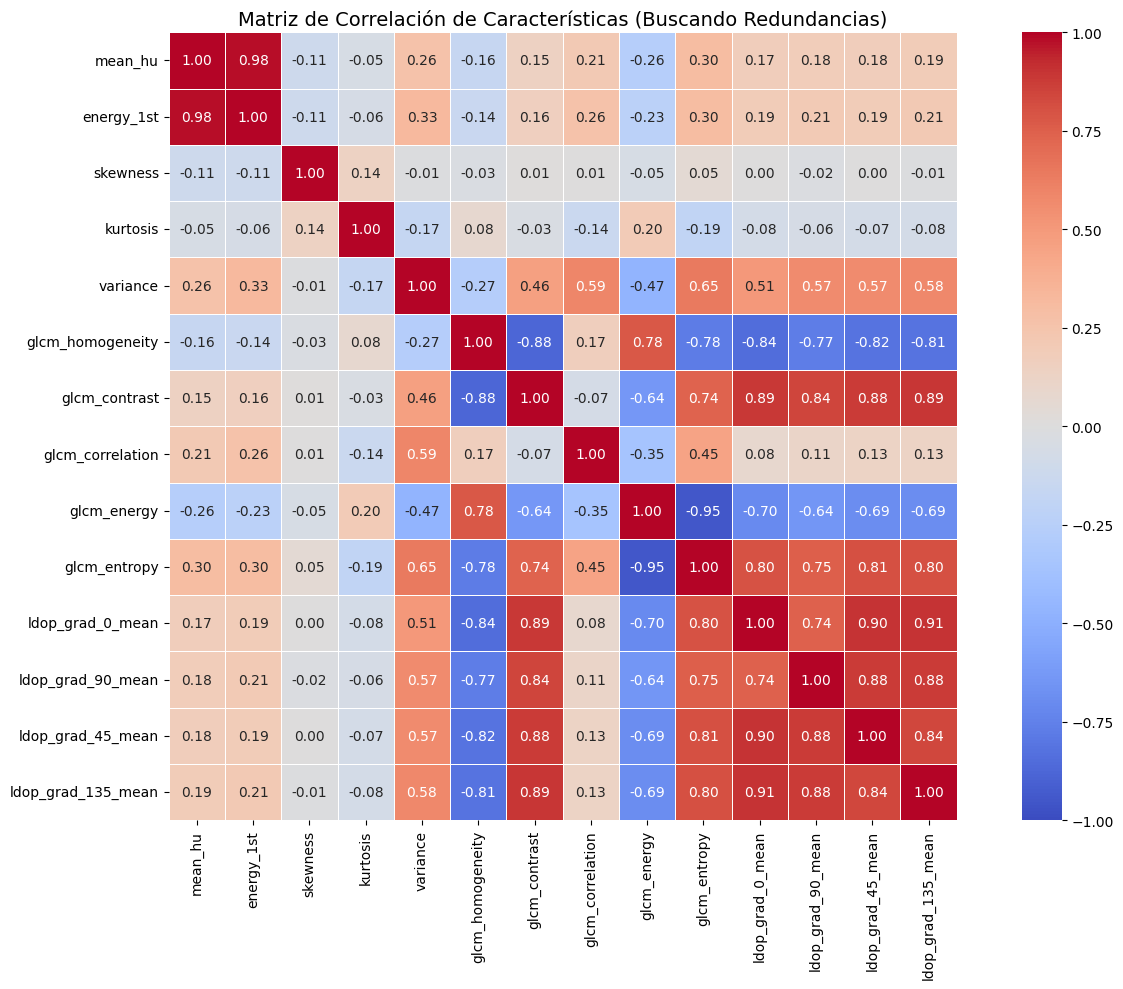

In [24]:
from feature_evaluation.feature_evaluator import FeatureEvaluator
evaluator = FeatureEvaluator(df_features, analysis = True)